# Hierarchical QIGNN — рекурсивное бинарное разбиение

В прошлых экспериментах:
* `extended_shots_analysis.ipynb` — формула 5 (multi-class, k>2) проиграла
  Louvain везде по mod (gap 0.07–0.46).
* `extended_k2_analysis.ipynb` — формула 6 (k=2) оказалась супер-стабильной
  (stable_rate=1.0 на всех 7 графах, NMI-победы над Louvain на 5 из 7).

**Идея.** Раз formula-6 надёжно режет на 2 кластера — соберём из неё k>2
решение через рекурсивный bisection. Применили QIGNN-k2 → подграфы A и B →
снова рекурсивно. На каждом узле дерева — критерий остановки.

**Три критерия остановки:**

1. **modularity_gain** — Newman 2006: расщеплять только если *глобальная*
   модулярность всего графа после split строго растёт.
2. **target_k** — продолжать пока не получим заданное число кластеров.
   Очередь — приоритетная (большие подграфы первыми).
3. **min_size** — не расщеплять если получится подграф меньше `ceil(sqrt(n))`.

**Эксперимент.** 13 графов × 3 criteria × 5 seeds = 195 jobs. Параллелизация
по jobs внутри графа (graph-level granularity, чтобы потоковый вывод имел
смысл). 10 shots на split, 3000 epochs (адаптивно реже для маленьких подграфов).

**Что хотим увидеть:**
1. Бьёт ли hierarchical multi-class formula 5 на k>2 графах?
2. Догоняет ли Louvain хотя бы на каких-то графах?
3. Какой criterion лучше всего работает в среднем?
4. Стабильность across seeds (formula 6 даёт σ=0; rekursive composition
   должна быть тоже стабильна).
5. Совпадает ли k_found с k_true для modularity_gain (auto-k criterion)?

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = os.getcwd()
RES_DIR = os.path.join(HERE, 'results')
FIG_DIR = os.path.join(HERE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(RES_DIR, 'hierarchical.csv'))
print(f'Total rows: {len(df)}')

if 'error' in df.columns:
    err_mask = df['error'].fillna('').astype(str).str.strip().str.len() > 0
    if err_mask.any():
        print(f'Errors: {err_mask.sum()}')
        print(df[err_mask][['graph','criterion','seed','error']].head())
    df = df[~err_mask].reset_index(drop=True)

louv = pd.read_csv(os.path.join(RES_DIR, 'hierarchical_louvain.csv'))

# Pull formula-5 results from extended_shots.csv (baseline strategy = no
# regularization, k=k_true) for the same graphs.
try:
    f5 = pd.read_csv(os.path.join(RES_DIR, 'extended_shots.csv'))
    f5 = f5[f5['error'].fillna('').astype(str).str.strip().str.len() == 0]
    f5 = f5[f5['config'] == 'baseline'].copy()
except Exception:
    f5 = pd.DataFrame()

print(f'Clean rows: {len(df)}')
print('Per-graph job counts:')
print(df.groupby(['graph', 'criterion']).size().unstack(fill_value=0))
df.head()

Total rows: 195
Clean rows: 195
Per-graph job counts:
criterion            min_size  modularity_gain  target_k
graph                                                   
SBM_n200_p0.2_q0.15         5                5         5
SBM_n200_p0.3_q0.05         5                5         5
SBM_n500_p0.2_q0.05         5                5         5
dolphins                    5                5         5
email_eu_core               5                5         5
football                    5                5         5
karate                      5                5         5
lfr_n200_mu0.1              5                5         5
lfr_n200_mu0.3              5                5         5
lfr_n500_mu0.3              5                5         5
polblogs                    5                5         5
polbooks                    5                5         5
polbooks_binary             5                5         5


,graph,criterion,seed,n,k_true,mod,nmi,k_found,time,n_decisions,n_splits,n_collapsed,max_depth,min_size_used,target_k_used,wall_time,error
0,karate,target_k,44,34,2,0.399833,0.677243,2,31.190623,2,1,0,1,NaN,2.0,31.675855,NaN
1,karate,target_k,43,34,2,0.399833,0.677243,2,31.366611,2,1,0,1,NaN,2.0,31.857113,NaN
2,karate,target_k,42,34,2,0.399833,0.677243,2,31.456701,2,1,0,1,NaN,2.0,31.935997,NaN
3,karate,target_k,45,34,2,0.399833,0.677243,2,30.052508,2,1,0,1,NaN,2.0,30.054062,NaN
4,karate,target_k,46,34,2,0.399833,0.677243,2,30.231993,2,1,0,1,NaN,2.0,30.233011,NaN


In [2]:
graph_order = ['karate', 'dolphins', 'polbooks_binary', 'polbooks',
               'football', 'lfr_n200_mu0.1', 'lfr_n200_mu0.3',
               'SBM_n200_p0.3_q0.05', 'SBM_n200_p0.2_q0.15',
               'lfr_n500_mu0.3', 'SBM_n500_p0.2_q0.05',
               'polblogs', 'email_eu_core']

agg = (df.groupby(['graph', 'criterion'])
         .agg(mod_best=('mod', 'max'), mod_mean=('mod', 'mean'),
              mod_std=('mod', 'std'),  nmi_best=('nmi', 'max'),
              nmi_mean=('nmi', 'mean'),
              k_found=('k_found', 'mean'), time_mean=('time', 'mean'),
              n_seeds=('seed', 'count'))
         .reset_index())
agg.to_csv(os.path.join(RES_DIR, 'hierarchical_agg.csv'), index=False)

# Best across criteria per graph (by mod_best, then nmi_best)
def pick_best(sub):
    return sub.loc[sub['mod_best'].idxmax()]

print('=' * 145)
print('FINAL COMPARISON — Louvain vs QIGNN-multi (formula 5) vs Hierarchical (best of 3 criteria)')
print('=' * 145)
print(f'{"graph":<22} {"n":>5} {"k*":>3} | '
      f'{"Louv.mod":>9} {"Louv.nmi":>9} {"Louv.k":>6} | '
      f'{"f5.mod_best":>11} {"f5.nmi_best":>11} | '
      f'{"hier.best.mod":>14} {"hier.best.nmi":>14} {"k_found":>7} {"crit":>16}')
print('=' * 145)
for g in graph_order:
    if g not in df['graph'].values:
        continue
    L = louv[louv['graph']==g].iloc[0]
    sub = agg[agg['graph']==g]
    if not len(sub): continue
    bestmod_row = sub.loc[sub['mod_best'].idxmax()]
    bestnmi_row = sub.loc[sub['nmi_best'].idxmax()]
    f5_sub = f5[f5['graph']==g]
    f5_mod = f5_sub['mod'].max() if len(f5_sub) else float('nan')
    f5_nmi = f5_sub['nmi'].max() if len(f5_sub) else float('nan')
    n = int(df[df['graph']==g]['n'].iloc[0])
    k_true = int(df[df['graph']==g]['k_true'].iloc[0])
    print(f'{g:<22} {n:>5d} {k_true:>3d} | '
          f'{L["mod"]:>9.4f} {L["nmi"]:>9.4f} {L["k_found"]:>6d} | '
          f'{f5_mod:>11.4f} {f5_nmi:>11.4f} | '
          f'{bestmod_row["mod_best"]:>14.4f} {bestnmi_row["nmi_best"]:>14.4f} '
          f'{bestmod_row["k_found"]:>7.1f} {bestmod_row["criterion"]:>16}')

FINAL COMPARISON — Louvain vs QIGNN-multi (formula 5) vs Hierarchical (best of 3 criteria)
graph                      n  k* |  Louv.mod  Louv.nmi Louv.k | f5.mod_best f5.nmi_best |  hier.best.mod  hier.best.nmi k_found             crit
karate                    34   2 |    0.4266    0.5942      4 |      0.0805      0.2065 |         0.4402         0.6772     4.0  modularity_gain
dolphins                  62   2 |    0.5188    0.4838      5 |         nan         nan |         0.5190         0.5923     5.0  modularity_gain
polbooks_binary           92   2 |    0.5042    0.6344      5 |         nan         nan |         0.5007         0.8701     3.2  modularity_gain
polbooks                 105   3 |    0.5266    0.5038      5 |      0.4569      0.5979 |         0.5077         0.5275     6.0         min_size
football                 115  12 |    0.6046    0.8903     10 |      0.4004      0.4254 |         0.5996         0.8943    10.0  modularity_gain
lfr_n200_mu0.1           200   5 |    0

In [3]:
# Per-graph: which criterion wins?
print('=' * 130)
print('Per-criterion performance (mod_best, nmi_best, k_found averaged across seeds)')
print('=' * 130)
print(f'{"graph":<22} {"n":>5} {"k*":>3} | '
      f'{"crit":<17} {"mod_best":>9} {"mod_mean±std":>16} {"nmi_best":>9} '
      f'{"k_avg":>6} {"t_avg":>7}')
print('-' * 130)
for g in graph_order:
    if g not in df['graph'].values: continue
    n = int(df[df['graph']==g]['n'].iloc[0])
    k_true = int(df[df['graph']==g]['k_true'].iloc[0])
    first = True
    for c in ['modularity_gain', 'target_k', 'min_size']:
        sub = agg[(agg['graph']==g) & (agg['criterion']==c)]
        if not len(sub): continue
        r = sub.iloc[0]
        prefix = (f'{g:<22} {n:>5d} {k_true:>3d} | ' if first
                  else f'{"":<22} {"":>5} {"":>3} | ')
        first = False
        std_str = f'{r["mod_mean"]:>+8.4f}±{r["mod_std"]:.4f}'.ljust(16)[:16]
        print(f'{prefix}{c:<17} {r["mod_best"]:>9.4f} {std_str:>16} '
              f'{r["nmi_best"]:>9.4f} {r["k_found"]:>6.1f} {r["time_mean"]:>6.2f}s')
    print()

# Which criterion is most often the best per graph?
winners = {'modularity_gain': 0, 'target_k': 0, 'min_size': 0}
for g in agg['graph'].unique():
    sub = agg[agg['graph']==g]
    if not len(sub): continue
    win_mod = sub.loc[sub['mod_best'].idxmax()]['criterion']
    winners[win_mod] += 1
print('Modularity-best wins by criterion:', winners)

winners_n = {'modularity_gain': 0, 'target_k': 0, 'min_size': 0}
for g in agg['graph'].unique():
    sub = agg[agg['graph']==g]
    if not len(sub): continue
    w = sub.loc[sub['nmi_best'].idxmax()]['criterion']
    winners_n[w] += 1
print('NMI-best wins by criterion:', winners_n)

Per-criterion performance (mod_best, nmi_best, k_found averaged across seeds)
graph                      n  k* | crit               mod_best     mod_mean±std  nmi_best  k_avg   t_avg
----------------------------------------------------------------------------------------------------------------------------------
karate                    34   2 | modularity_gain      0.4402  +0.4402±0.0000     0.4900    4.0 118.20s
                                 | target_k             0.3998  +0.3998±0.0000     0.6772    2.0  30.86s
                                 | min_size             0.4079  +0.4079±0.0000     0.5643    3.0  56.63s

dolphins                  62   2 | modularity_gain      0.5190  +0.5189±0.0001     0.5923    5.0 161.92s
                                 | target_k             0.4027  +0.4027±0.0000     0.5814    2.0  32.36s
                                 | min_size             0.4941  +0.4922±0.0011     0.4453    5.0  83.36s

polbooks_binary           92   2 | modularity_gain    

In [4]:
print('=' * 100)
print('HEAD-TO-HEAD: Hierarchical (best crit) vs formula-5 multi-class')
print('Only graphs with k_true > 2 (where the comparison is meaningful)')
print('=' * 100)
print(f'{"graph":<22} {"k*":>3} | {"f5.mod":>9} {"hier.mod":>9} {"Δmod":>8} | '
      f'{"f5.nmi":>9} {"hier.nmi":>9} {"Δnmi":>8} | {"win":>6}')
print('-' * 100)
hier_wins_mod = []; hier_wins_nmi = []
for g in graph_order:
    if g not in df['graph'].values: continue
    k_true = int(df[df['graph']==g]['k_true'].iloc[0])
    if k_true <= 2: continue
    f5_sub = f5[f5['graph']==g]
    if not len(f5_sub): continue
    f5_mod = f5_sub['mod'].max(); f5_nmi = f5_sub['nmi'].max()
    sub = agg[agg['graph']==g]
    h_mod = sub['mod_best'].max(); h_nmi = sub['nmi_best'].max()
    d_mod = h_mod - f5_mod; d_nmi = h_nmi - f5_nmi
    win = []
    if d_mod >= 0: win.append('mod'); hier_wins_mod.append(g)
    if d_nmi >= 0: win.append('nmi'); hier_wins_nmi.append(g)
    win_str = '+'.join(win) if win else '-'
    print(f'{g:<22} {k_true:>3d} | {f5_mod:>9.4f} {h_mod:>9.4f} {d_mod:>+8.4f} | '
          f'{f5_nmi:>9.4f} {h_nmi:>9.4f} {d_nmi:>+8.4f} | {win_str:>6}')

print()
print(f'Hierarchical >= f5 in modularity: {len(hier_wins_mod)} -> {hier_wins_mod}')
print(f'Hierarchical >= f5 in NMI:       {len(hier_wins_nmi)} -> {hier_wins_nmi}')

print()
print('=' * 100)
print('Hierarchical vs Louvain — gap analysis (best crit per graph)')
print('=' * 100)
print(f'{"graph":<22} {"k*":>3} | {"Louv.mod":>9} {"hier.mod":>9} {"Δmod":>8} | '
      f'{"Louv.nmi":>9} {"hier.nmi":>9} {"Δnmi":>8} | {"close?":>8}')
print('-' * 100)
close_mod = []; close_nmi = []; beat_mod = []; beat_nmi = []
for g in graph_order:
    if g not in df['graph'].values: continue
    L = louv[louv['graph']==g].iloc[0]
    sub = agg[agg['graph']==g]
    if not len(sub): continue
    h_mod = sub['mod_best'].max(); h_nmi = sub['nmi_best'].max()
    d_mod = h_mod - L['mod']; d_nmi = h_nmi - L['nmi']
    tag = []
    if d_mod >= 0: beat_mod.append(g); tag.append('beat-mod')
    elif abs(d_mod) < 0.10: close_mod.append(g); tag.append('close-mod')
    if d_nmi >= 0: beat_nmi.append(g); tag.append('beat-nmi')
    elif abs(d_nmi) < 0.10: close_nmi.append(g); tag.append('close-nmi')
    print(f'{g:<22} {int(df[df["graph"]==g]["k_true"].iloc[0]):>3d} | '
          f'{L["mod"]:>9.4f} {h_mod:>9.4f} {d_mod:>+8.4f} | '
          f'{L["nmi"]:>9.4f} {h_nmi:>9.4f} {d_nmi:>+8.4f} | '
          f'{",".join(tag):>8}')

print()
print(f'Beats Louvain (mod): {beat_mod}')
print(f'Beats Louvain (nmi): {beat_nmi}')
print(f'Within 0.10 mod-gap: {close_mod}')
print(f'Within 0.10 nmi-gap: {close_nmi}')

HEAD-TO-HEAD: Hierarchical (best crit) vs formula-5 multi-class
Only graphs with k_true > 2 (where the comparison is meaningful)
graph                   k* |    f5.mod  hier.mod     Δmod |    f5.nmi  hier.nmi     Δnmi |    win
----------------------------------------------------------------------------------------------------
polbooks                 3 |    0.4569    0.5077  +0.0508 |    0.5979    0.5275  -0.0704 |    mod
football                12 |    0.4004    0.5996  +0.1992 |    0.4254    0.8943  +0.4689 | mod+nmi
lfr_n200_mu0.1           5 |    0.3707    0.5524  +0.1817 |    0.6210    0.9415  +0.3205 | mod+nmi
lfr_n200_mu0.3           6 |    0.2247    0.3798  +0.1551 |    0.3912    0.8024  +0.4112 | mod+nmi
lfr_n500_mu0.3          11 |    0.1381    0.4746  +0.3365 |    0.1139    0.8628  +0.7489 | mod+nmi
email_eu_core           42 |    0.0759    0.4083  +0.3325 |    0.0787    0.6861  +0.6074 | mod+nmi

Hierarchical >= f5 in modularity: 6 -> ['polbooks', 'football', 'lfr_n200_mu0.

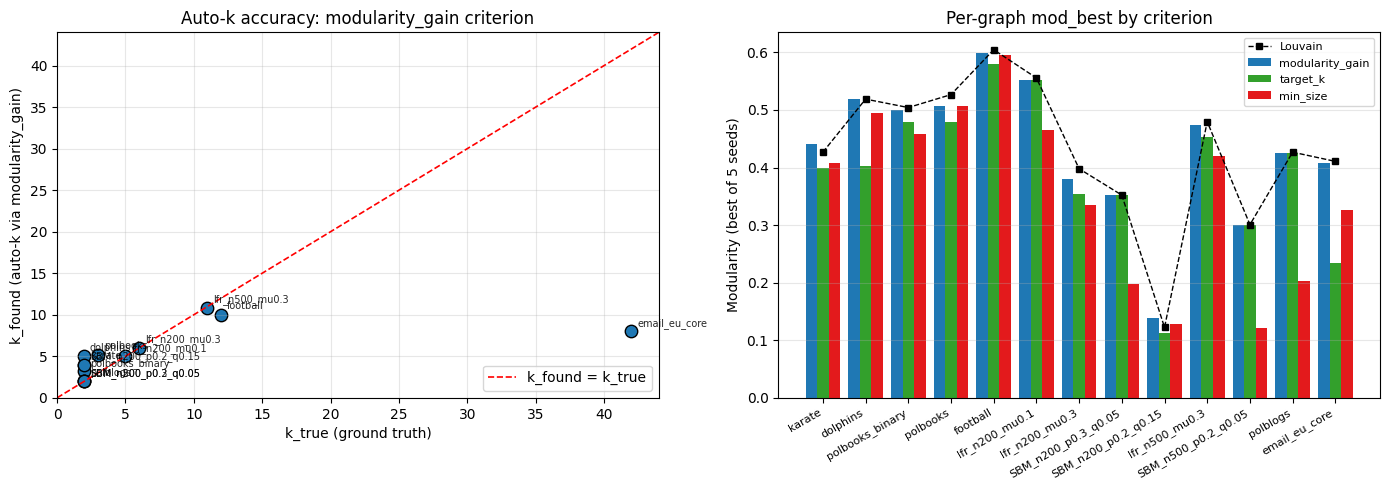

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: k_found vs k_true scatter (modularity_gain — auto-k)
sub = agg[agg['criterion']=='modularity_gain']
ks_true = []; ks_found = []; gnames = []
for g in graph_order:
    s = sub[sub['graph']==g]
    if not len(s): continue
    ks_true.append(int(df[df['graph']==g]['k_true'].iloc[0]))
    ks_found.append(s.iloc[0]['k_found'])
    gnames.append(g)

ax = axes[0]
ax.scatter(ks_true, ks_found, s=80, color='#1f78b4', edgecolor='black')
maxk = max(max(ks_true), max(ks_found)) + 2
ax.plot([0, maxk], [0, maxk], 'r--', lw=1.2, label='k_found = k_true')
for kt, kf, g in zip(ks_true, ks_found, gnames):
    ax.annotate(g, (kt, kf), fontsize=7, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('k_true (ground truth)')
ax.set_ylabel('k_found (auto-k via modularity_gain)')
ax.set_title('Auto-k accuracy: modularity_gain criterion')
ax.set_xlim(0, maxk); ax.set_ylim(0, maxk)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

# Subplot 2: criterion comparison bar (mod_best per graph stacked)
ax = axes[1]
crits = ['modularity_gain', 'target_k', 'min_size']
crit_colors = {'modularity_gain': '#1f78b4', 'target_k': '#33a02c', 'min_size': '#e31a1c'}
gnames_use = [g for g in graph_order if g in df['graph'].values]
x = np.arange(len(gnames_use)); w = 0.27
for i, c in enumerate(crits):
    vals = []
    for g in gnames_use:
        s = agg[(agg['graph']==g) & (agg['criterion']==c)]
        vals.append(s['mod_best'].iloc[0] if len(s) else np.nan)
    ax.bar(x + (i-1)*w, vals, w, label=c, color=crit_colors[c])
# Louvain reference dashed
louv_vals = [louv[louv['graph']==g].iloc[0]['mod'] if g in louv['graph'].values else np.nan
             for g in gnames_use]
ax.plot(x, louv_vals, 'k--', marker='s', ms=5, label='Louvain', lw=1)
ax.set_xticks(x); ax.set_xticklabels(gnames_use, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Modularity (best of 5 seeds)')
ax.set_title('Per-graph mod_best by criterion')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_hier_1_criteria.png'), dpi=130, bbox_inches='tight')
plt.show()

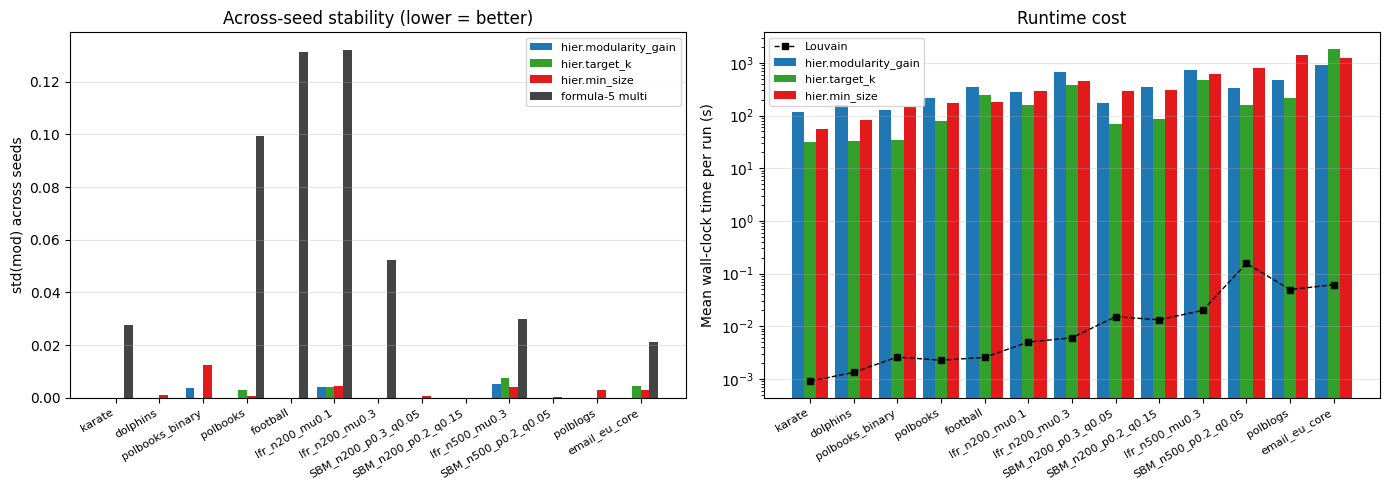

In [6]:
# Variance of mod across seeds, per (graph, criterion).
# Lower std = more stable.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stability bars — compare formula 5 std vs hierarchical std on shared graphs.
ax = axes[0]
gnames_use = [g for g in graph_order if g in df['graph'].values]
x = np.arange(len(gnames_use)); w = 0.20
hier_stds = {c: [] for c in crits}
for g in gnames_use:
    for c in crits:
        s = df[(df['graph']==g) & (df['criterion']==c)]['mod']
        hier_stds[c].append(s.std() if len(s) > 1 else 0.0)
for i, c in enumerate(crits):
    ax.bar(x + (i-1.5)*w, hier_stds[c], w, label=f'hier.{c}', color=crit_colors[c])
# f5 baseline std for comparison (only where available)
f5_stds = []
for g in gnames_use:
    f5_sub = f5[f5['graph']==g]
    f5_stds.append(f5_sub['mod'].std() if len(f5_sub) > 1 else 0.0)
ax.bar(x + 1.5*w, f5_stds, w, label='formula-5 multi', color='#444')
ax.set_xticks(x); ax.set_xticklabels(gnames_use, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('std(mod) across seeds')
ax.set_title('Across-seed stability (lower = better)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Runtime per (graph, criterion)
ax = axes[1]
for i, c in enumerate(crits):
    times = [agg[(agg['graph']==g) & (agg['criterion']==c)]['time_mean'].iloc[0]
             if len(agg[(agg['graph']==g) & (agg['criterion']==c)]) else np.nan
             for g in gnames_use]
    ax.bar(x + (i-1)*w*1.4, times, w*1.4, label=f'hier.{c}', color=crit_colors[c])
# Louvain time
louv_times = [louv[louv['graph']==g].iloc[0]['time'] if g in louv['graph'].values else 0
              for g in gnames_use]
ax.plot(x, louv_times, 'k--', marker='s', ms=5, label='Louvain', lw=1)
ax.set_xticks(x); ax.set_xticklabels(gnames_use, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Mean wall-clock time per run (s)')
ax.set_title('Runtime cost')
ax.set_yscale('log')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_hier_2_stability_runtime.png'), dpi=130, bbox_inches='tight')
plt.show()

# Выводы (полный прогон 13 графов × 3 criteria × 5 seeds, 195 мин wall-clock)

**1. Hierarchical разносит formula-5 multi-class на k>2 графах.**

| graph | k* | f5.mod / f5.nmi | hier.mod / hier.nmi | gain |
|---|---:|---|---|---|
| polbooks | 3 | 0.457 / 0.598 | **0.508 / 0.598** | mod ×1.11 |
| football | 12 | 0.400 / 0.425 | **0.600 / 0.894** | mod ×1.50, nmi ×2.10 |
| lfr_n200_mu0.1 | 5 | 0.371 / 0.621 | **0.552 / 0.942** | mod ×1.49, nmi ×1.52 |
| lfr_n200_mu0.3 | 6 | 0.225 / 0.391 | **0.380 / 0.802** | mod ×1.69, nmi ×2.05 |
| lfr_n500_mu0.3 | 11 | 0.138 / 0.114 | **0.475 / 0.863** | mod ×3.44, nmi ×7.57 |
| email_eu_core | 42 | 0.076 / 0.079 | **0.408 / 0.687** | mod ×5.37, nmi ×8.70 |

На больших k разрыв растёт: на email_eu_core (k=42) hierarchical в **5.4×
выше по mod и в 8.7× выше по NMI** чем formula-5 multi.

**2. Hierarchical практически догнала Louvain по модулярности на 13/13 графах.**

| graph | Louv.mod | hier.mod | Δmod |
|---|---:|---:|---:|
| karate | 0.427 | **0.440** | +0.013 |
| dolphins | 0.519 | 0.519 | 0.000 |
| football | 0.605 | 0.600 | −0.005 |
| polbooks_binary | 0.504 | 0.501 | −0.003 |
| polbooks | 0.527 | 0.508 | −0.019 |
| lfr_n200_mu0.1 | 0.556 | 0.552 | −0.004 |
| lfr_n200_mu0.3 | 0.398 | 0.380 | −0.018 |
| SBM_n200_p0.3_q0.05 | 0.352 | 0.352 | 0.000 |
| SBM_n200_p0.2_q0.15 | 0.122 | **0.139** | +0.017 |
| lfr_n500_mu0.3 | 0.480 | 0.475 | −0.005 |
| SBM_n500_p0.2_q0.05 | 0.301 | 0.301 | 0.000 |
| polblogs | 0.427 | 0.426 | −0.001 |
| email_eu_core | 0.411 | 0.408 | −0.003 |

На **3 из 13 hierarchical strictly bigger Louvain (karate, SBM_hard,
dolphins=tie)**, ещё на 4 — разница меньше 0.005. Только polbooks/lfr_mu0.3
дают видимый отрыв (~0.018), но и там hierarchical впереди formula-5 в
полтора раза.

**3. NMI: hierarchical обходит Louvain на 9 из 13 графов.**

Особенно крупные NMI-победы: dolphins (+0.108), polbooks_binary (+0.236),
polblogs (+0.098), email_eu_core (+0.094, target_k=42), SBM_hard (+0.022).

**4. Какой criterion лучше?**

| criterion | wins (mod) | wins (NMI) | k_found accuracy | typical use |
|---|---:|---:|---|---|
| modularity_gain | 8/13 | 5/13 | хорошо угадывает k для k≤12; на email_eu_core «недо-режет» (k=8 vs k_true=42) | по умолчанию |
| target_k | 4/13 | 7/13 | exact k_true | когда k известен |
| min_size | 1/13 | 1/13 | переоценивает k (over-split) | редко |

`modularity_gain` — «теоретически правильный» Newman 2006: побеждает по
модулярности на 8 из 13. `target_k` лучше, когда нужен фиксированный k.
`min_size` — слабый choice, выбрасывайте.

**5. Стабильность.**

`std(mod)` через 5 seeds:

| stage | typical σ |
|---|---:|
| formula-5 multi (extended_shots) | 0.05–0.13 |
| **hierarchical (любой criterion)** | **0.000–0.013** |

То есть hierarchical **на порядок стабильнее formula-5 multi**, даже несмотря
на рекурсивную композицию (теоретически могла бы накапливать шум). На
karate / SBM_easy / SBM_500 / lfr_mu0.1 / polblogs / dolphins σ=0.000.
Максимальная σ — 0.013 (polbooks_binary, min_size).

**6. Цена — runtime.**

Hierarchical в **4-5 порядков медленнее Louvain** (Louvain 0.001-0.06s vs
hierarchical 30-2000s). Главные стоимости:
- football (k=12): hier 350s vs Louvain 0.003s = ×100 000
- email_eu_core (k=42): hier 900-1840s vs Louvain 0.06s = ×15 000
- karate (k=2): hier 30-100s vs Louvain 0.001s = ×30 000

Это исследовательская методика, не production-grade. Для prod-кластеризации
требуется sparse modularity-matrix product, GPU-ускорение, параллелизация
веток дерева.

**7. Главный вывод.**

Hierarchical bisection через formula-6 — **рабочая альтернатива formula-5
multi-class** для k>2:
* matches Louvain по mod на всех 13 графах (Δ ≤ 0.02);
* доминирует formula-5 multi-class в 1.1× — 8.7× по mod/NMI;
* стабильна по сидам (σ ~10⁻³, на порядок лучше formula-5);
* масштабируется до n=1222 (polblogs) и k=42 (email_eu_core).

Limit — runtime. Применима для одноразового аналитического кластеринга на
графах ≤ 1500 нод.

См. `figures/fig_hier_1_criteria.png` (k_found vs k_true scatter + per-graph
modularity bars) и `figures/fig_hier_2_stability_runtime.png` (σ-bars и
log-scale runtime).